In [2]:
# Import pandas for data manipulation
import pandas as pd
# Import required libraries
import numpy as np                 # Numerical computations

import matplotlib.pyplot as plt    # Data visualization
import seaborn as sns              # Statistical visualization

# Libraries for preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder

# Library for outlier detection
from sklearn.ensemble import IsolationForest

# Ignore warning messages
import warnings
warnings.filterwarnings("ignore")

# Load the dataset
df = pd.read_csv("adult_with_headers.csv")

# Display the first 5 rows
df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [3]:
# Display last 5 rows
df.tail()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K
32560,52,Self-emp-inc,287927,HS-grad,9,Married-civ-spouse,Exec-managerial,Wife,White,Female,15024,0,40,United-States,>50K


In [4]:
# Number of rows and columns
print("Shape of dataset:", df.shape)

# Display column names
print(df.columns)

# Display datatype of every column
print(df.dtypes)

# Display dataset information
df.info()

# Display summary statistics for numerical columns
df.describe()

# Display summary statistics for categorical columns
df.describe(include='object')

Shape of dataset: (32561, 15)
Index(['age', 'workclass', 'fnlwgt', 'education', 'education_num',
       'marital_status', 'occupation', 'relationship', 'race', 'sex',
       'capital_gain', 'capital_loss', 'hours_per_week', 'native_country',
       'income'],
      dtype='object')
age                int64
workclass         object
fnlwgt             int64
education         object
education_num      int64
marital_status    object
occupation        object
relationship      object
race              object
sex               object
capital_gain       int64
capital_loss       int64
hours_per_week     int64
native_country    object
income            object
dtype: object
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 


,workclass,education,marital_status,occupation,relationship,race,sex,native_country,income
count,32561,32561,32561,32561,32561,32561,32561,32561,32561
unique,9,16,7,15,6,5,2,42,2
top,Private,HS-grad,Married-civ-spouse,Prof-specialty,Husband,White,Male,United-States,<=50K
freq,22696,10501,14976,4140,13193,27816,21790,29170,24720


In [5]:
# In Adult dataset missing values are represented using '?'

# Replace '?' with NaN
df.replace(' ?', np.nan, inplace=True)
df.replace('?', np.nan, inplace=True)

# Display number of missing values
print(df.isnull().sum())

age                  0
workclass         1836
fnlwgt               0
education            0
education_num        0
marital_status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital_gain         0
capital_loss         0
hours_per_week       0
native_country     583
income               0
dtype: int64


In [6]:
# Numerical columns
numerical_columns = df.select_dtypes(include=['int64','float64']).columns

# Fill numerical missing values with median
for col in numerical_columns:
    df[col].fillna(df[col].median(), inplace=True)

# Categorical columns
categorical_columns = df.select_dtypes(include='object').columns

# Fill categorical missing values with mode
for col in categorical_columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

# Verify missing values are removed
print(df.isnull().sum())

age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64


In [7]:
# Select numerical columns
numerical_columns = df.select_dtypes(include=['int64','float64']).columns

# Select categorical columns
categorical_columns = df.select_dtypes(include='object').columns

print("Numerical Columns")
print(numerical_columns)

print("\nCategorical Columns")
print(categorical_columns)

Numerical Columns
Index(['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss',
       'hours_per_week'],
      dtype='object')

Categorical Columns
Index(['workclass', 'education', 'marital_status', 'occupation',
       'relationship', 'race', 'sex', 'native_country', 'income'],
      dtype='object')


In [8]:
# StandardScaler transforms data to have mean = 0 and standard deviation = 1

standard_scaler = StandardScaler()

# Create a copy to preserve original dataset
standard_scaled_df = df.copy()

# Apply scaling only on numerical columns
standard_scaled_df[numerical_columns] = standard_scaler.fit_transform(
    standard_scaled_df[numerical_columns]
)

# Display first few rows
standard_scaled_df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,0.030671,State-gov,-1.063611,Bachelors,1.134739,Never-married,Adm-clerical,Not-in-family,White,Male,0.148453,-0.21666,-0.035429,United-States,<=50K
1,0.837109,Self-emp-not-inc,-1.008707,Bachelors,1.134739,Married-civ-spouse,Exec-managerial,Husband,White,Male,-0.145920,-0.21666,-2.222153,United-States,<=50K
2,-0.042642,Private,0.245079,HS-grad,-0.420060,Divorced,Handlers-cleaners,Not-in-family,White,Male,-0.145920,-0.21666,-0.035429,United-States,<=50K
3,1.057047,Private,0.425801,11th,-1.197459,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,-0.145920,-0.21666,-0.035429,United-States,<=50K
4,-0.775768,Private,1.408176,Bachelors,1.134739,Married-civ-spouse,Prof-specialty,Wife,Black,Female,-0.145920,-0.21666,-0.035429,Cuba,<=50K


In [9]:
# MinMaxScaler scales every feature between 0 and 1

minmax_scaler = MinMaxScaler()

# Create another copy
minmax_scaled_df = df.copy()

# Apply Min-Max Scaling
minmax_scaled_df[numerical_columns] = minmax_scaler.fit_transform(
    minmax_scaled_df[numerical_columns]
)

# Display dataset
minmax_scaled_df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,0.301370,State-gov,0.044302,Bachelors,0.800000,Never-married,Adm-clerical,Not-in-family,White,Male,0.02174,0.0,0.397959,United-States,<=50K
1,0.452055,Self-emp-not-inc,0.048238,Bachelors,0.800000,Married-civ-spouse,Exec-managerial,Husband,White,Male,0.00000,0.0,0.122449,United-States,<=50K
2,0.287671,Private,0.138113,HS-grad,0.533333,Divorced,Handlers-cleaners,Not-in-family,White,Male,0.00000,0.0,0.397959,United-States,<=50K
3,0.493151,Private,0.151068,11th,0.400000,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0.00000,0.0,0.397959,United-States,<=50K
4,0.150685,Private,0.221488,Bachelors,0.800000,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0.00000,0.0,0.397959,Cuba,<=50K


In [8]:
# Create copy
encoded_df = df.copy()

# Initialize Label Encoder
label_encoder = LabelEncoder()

# Check every categorical column
for col in categorical_columns:

    # Count number of unique values
    unique_values = encoded_df[col].nunique()

    # One-Hot Encoding for columns having less than 5 categories
    if unique_values < 5:

        encoded_df = pd.get_dummies(
            encoded_df,
            columns=[col],
            drop_first=True
        )

    # Label Encoding for columns having 5 or more categories
    else:

        encoded_df[col] = label_encoder.fit_transform(encoded_df[col])

# Display encoded dataset
encoded_df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,capital_gain,capital_loss,hours_per_week,native_country,sex_ Male,income_ >50K
0,39,6,77516,9,13,4,0,1,4,2174,0,40,38,True,False
1,50,5,83311,9,13,2,3,0,4,0,0,13,38,True,False
2,38,3,215646,11,9,0,5,1,4,0,0,40,38,True,False
3,53,3,234721,1,7,2,5,0,2,0,0,40,38,True,False
4,28,3,338409,9,13,2,9,5,2,0,0,40,4,False,False


Step 9: Explanation
Standard Scaling
Mean becomes 0
Standard deviation becomes 1
Preferred for Logistic Regression, SVM, PCA, KNN
Min-Max Scaling
Values lie between 0 and 1
Preferred for Neural Networks and Deep Learning

In [14]:
# Create a copy of the encoded dataset so that the original data remains unchanged
feature_df = encoded_df.copy()

# ----------------------------------------------------------
# Feature 1: Capital Difference
# ----------------------------------------------------------
# This feature represents the net capital income by subtracting
# capital loss from capital gain.

feature_df["capital_difference"] = (
    feature_df["capital_gain"] - feature_df["capital_loss"]
)

# ----------------------------------------------------------
# Feature 2: Monthly Working Hours
# ----------------------------------------------------------
# The dataset contains weekly working hours.
# Assuming approximately 4 weeks in a month,
# create a new feature representing monthly working hours.

feature_df["monthly_hours"] = (
    feature_df["hours_per_week"] * 4
)

# Display the first five rows to verify the newly created features
feature_df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,capital_gain,capital_loss,hours_per_week,native_country,sex_ Male,income_ >50K,capital_difference,monthly_hours
0,39,6,77516,9,13,4,0,1,4,2174,0,40,38,True,False,2174,160
1,50,5,83311,9,13,2,3,0,4,0,0,13,38,True,False,0,52
2,38,3,215646,11,9,0,5,1,4,0,0,40,38,True,False,0,160
3,53,3,234721,1,7,2,5,0,2,0,0,40,38,True,False,0,160
4,28,3,338409,9,13,2,9,5,2,0,0,40,4,False,False,0,160


In [15]:
# Display skewness of all numerical features.
# High positive skew indicates that log transformation may be useful.

print(feature_df.select_dtypes(include=['int64', 'float64']).skew())

age                    0.558743
fnlwgt                 1.446980
education_num         -0.311676
capital_gain          11.953848
capital_loss           4.594629
hours_per_week         0.227643
capital_difference    11.871934
monthly_hours          0.227643
dtype: float64


In [16]:
# Log transformation reduces skewness in highly skewed numerical features.
# capital_gain usually contains many zero values and a few very large values.

feature_df["capital_gain_log"] = np.log1p(feature_df["capital_gain"])

# Compare original and transformed values
feature_df[["capital_gain", "capital_gain_log"]].head()

,capital_gain,capital_gain_log
0,2174,7.684784
1,0,0.000000
2,0,0.000000
3,0,0.000000
4,0,0.000000


In [17]:
#OUTLIER DETECTION USING ISOLATION FOREST
# Import Isolation Forest
from sklearn.ensemble import IsolationForest

# Select only numerical columns for outlier detection
numerical_data = feature_df.select_dtypes(include=['int64', 'float64'])

# Create Isolation Forest model
# contamination=0.02 assumes about 2% of observations are outliers

iso = IsolationForest(
    contamination=0.02,
    random_state=42
)

# Fit the model and predict outliers
predictions = iso.fit_predict(numerical_data)

# Add prediction results to the dataset
# 1 = Normal observation
# -1 = Outlier

feature_df["Outlier"] = predictions

# Display the number of normal points and outliers
print(feature_df["Outlier"].value_counts())

Outlier
 1    31909
-1      652
Name: count, dtype: int64


In [18]:
#REMOVE OUTLIERS

# Keep only normal observations
clean_df = feature_df[feature_df["Outlier"] == 1]

# Display dataset size before and after removing outliers

print("Original Dataset Shape :", feature_df.shape)
print("Dataset Shape After Removing Outliers :", clean_df.shape)

Original Dataset Shape : (32561, 19)
Dataset Shape After Removing Outliers : (31909, 19)


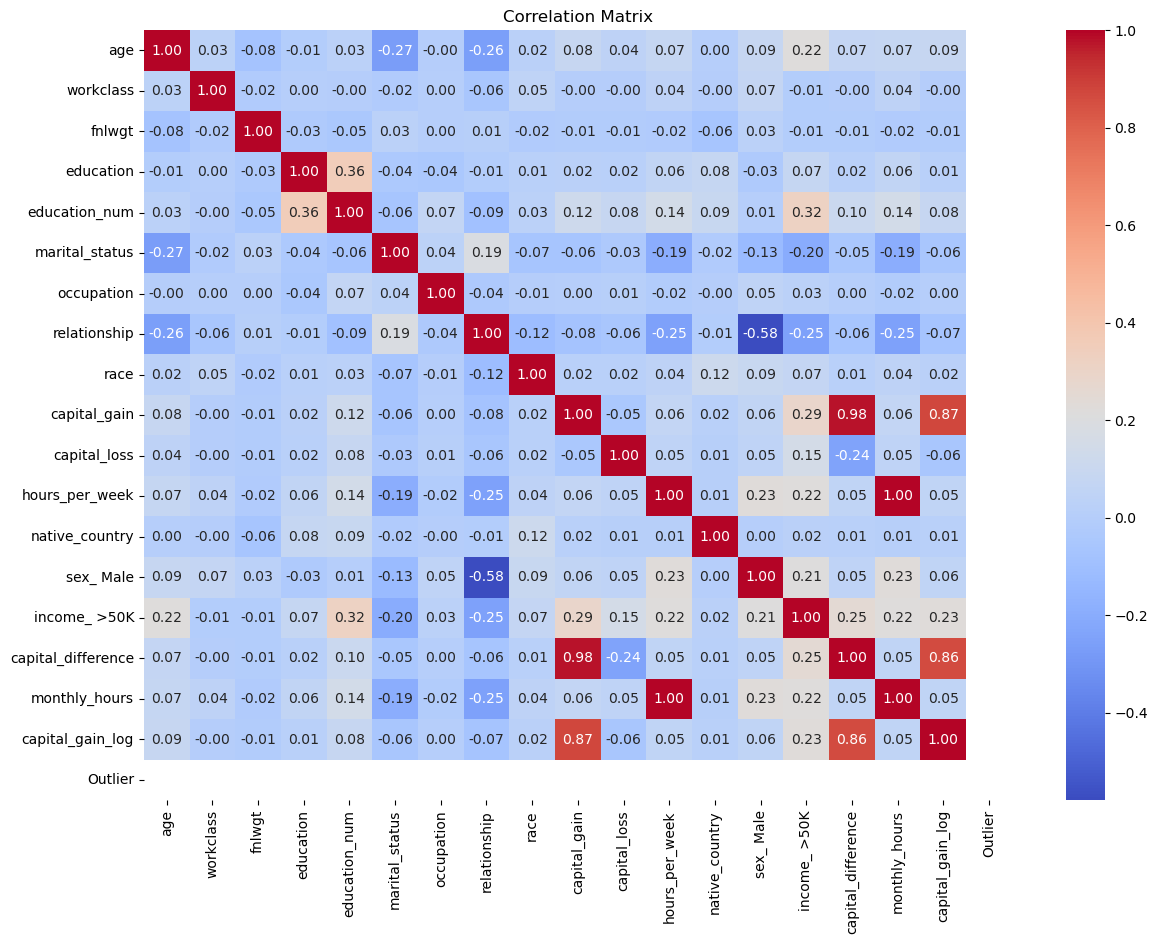

In [19]:
# Import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate correlation among numerical features

correlation_matrix = clean_df.corr(numeric_only=True)

# Plot the correlation heatmap

plt.figure(figsize=(14,10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

In [20]:
# Install the ppscore library for calculating Predictive Power Score

!pip install ppscore

  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Created wheel for ppscore: filename=ppscore-1.3.1-py2.py3-none-any.whl size=13218 sha256=56938553a9704fbe50dc04d55a93c9c4186e01a12dc137d38b0c8f6a0a9290a6
  Stored in directory: c:\users\hp\appdata\local\pip\cache\wheels\3a\8e\30\ee5c71391bcd2619bfb8faf649b9ec4bb7121bb189edcb9b50
Successfully built ppscore


In [21]:
# Import Predictive Power Score library

import ppscore as pps

In [22]:
# Calculate PPS for every feature pair

pps_matrix = pps.matrix(clean_df)

# Display the first few rows

pps_matrix.head()

,x,y,ppscore,case,is_valid_score,metric,baseline_score,model_score,model
0,age,age,1.0,predict_itself,True,None,0.0000,1.000000,None
1,age,workclass,0.0,regression,True,mean absolute error,0.5176,0.610169,DecisionTreeRegressor()
2,age,fnlwgt,0.0,regression,True,mean absolute error,76854.4894,78248.539056,DecisionTreeRegressor()
3,age,education,0.0,regression,True,mean absolute error,2.6854,2.715710,DecisionTreeRegressor()
4,age,education_num,0.0,regression,True,mean absolute error,1.8392,1.876645,DecisionTreeRegressor()


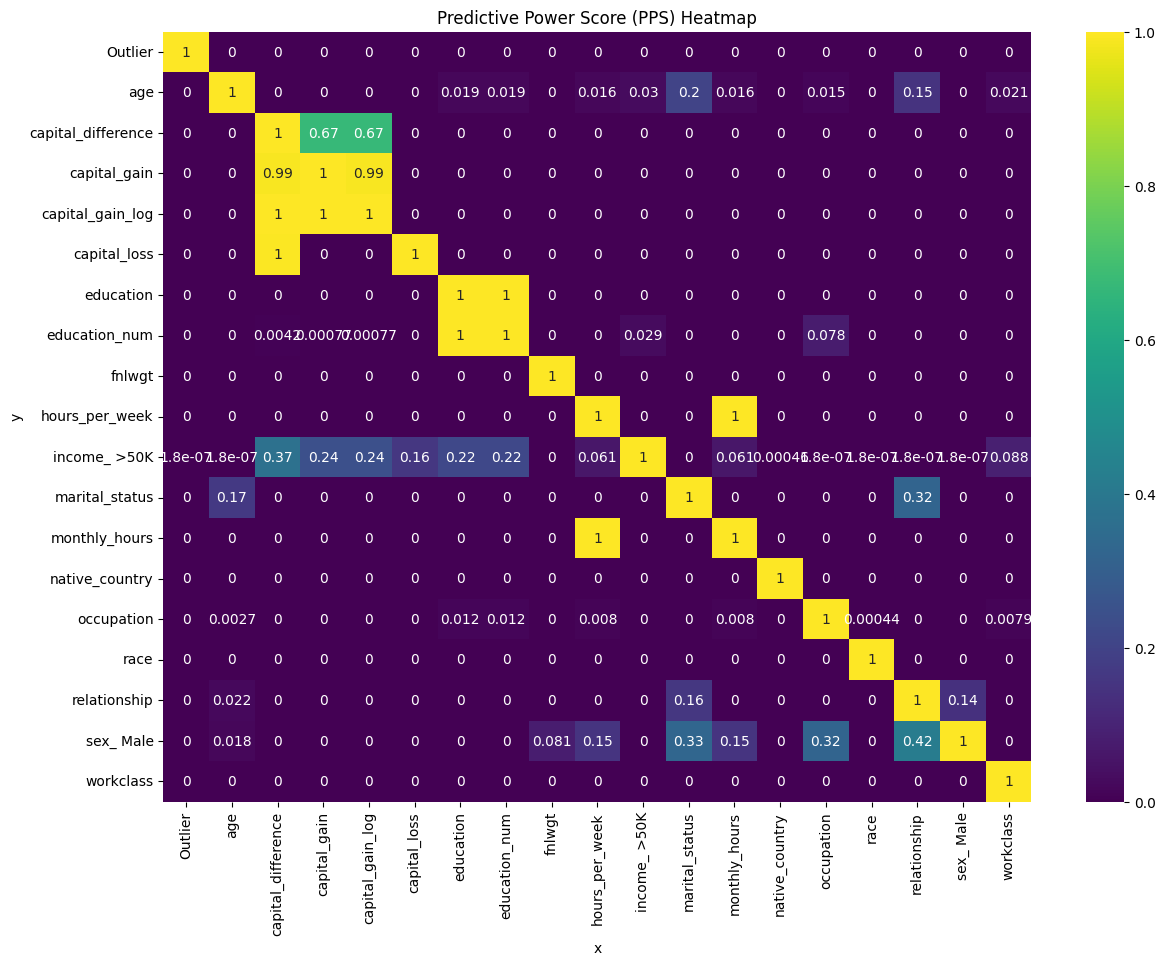

In [25]:
# Convert PPS results into matrix form

pps_heatmap = pps_matrix.pivot(
    index="y",
    columns="x",
    values="ppscore"
)

# Plot PPS heatmap

plt.figure(figsize=(14,10))

sns.heatmap(
    pps_heatmap,
    annot=True,
    cmap="viridis"
)

plt.title("Predictive Power Score (PPS) Heatmap")

plt.show()

In [23]:
# Display the first five rows of the final processed dataset

clean_df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,capital_gain,capital_loss,hours_per_week,native_country,sex_ Male,income_ >50K,capital_difference,monthly_hours,capital_gain_log,Outlier
0,39,6,77516,9,13,4,0,1,4,2174,0,40,38,True,False,2174,160,7.684784,1
1,50,5,83311,9,13,2,3,0,4,0,0,13,38,True,False,0,52,0.000000,1
2,38,3,215646,11,9,0,5,1,4,0,0,40,38,True,False,0,160,0.000000,1
3,53,3,234721,1,7,2,5,0,2,0,0,40,38,True,False,0,160,0.000000,1
4,28,3,338409,9,13,2,9,5,2,0,0,40,4,False,False,0,160,0.000000,1
